# Excited States: H2

This notebook introduces excited-state workflows for the hydrogen molecule
**H2**.

Goals:

- compute a ground-state VQE reference
- run several excited-state methods
- compare the returned excitation or energy estimates
- compare against the exact spectrum

This notebook is a small first comparison across the excited-state tools in
the repository.

In [ ]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from common.hamiltonian import get_exact_spectrum
from vqe.lr_vqe import run_lr_vqe
from vqe.qse import run_qse
from vqe.vqd import run_vqd

## Why excited states?

Ground-state VQE targets the lowest eigenvalue of the Hamiltonian.

Many chemistry questions also depend on low-lying excited states, so we need
methods that go beyond direct ground-state minimization.

This repository includes two broad families:

- **post-VQE methods** such as QSE and LR-VQE
- **variational excited-state methods** such as VQD

## Exact spectrum

For a small system like `H2`, we can compare approximate excited-state results
against exact diagonalization.

In [2]:
molecule = "H2"
mapping = "jordan_wigner"

exact_spectrum = np.asarray(get_exact_spectrum(molecule, mapping=mapping), dtype=float)
exact_spectrum = np.sort(exact_spectrum)

exact_spectrum[:8]

array([-1.13727017, -0.53870958, -0.53870958, -0.53247901, -0.53247901,
       -0.53247901, -0.44698573, -0.44698573])

In [3]:
exact_ground_energy = float(exact_spectrum[0])
exact_excitation_energies = exact_spectrum[:4] - exact_ground_energy

print("Exact energies:")
for i, e in enumerate(exact_spectrum[:4]):
    print(f"state {i}: {e:.10f}")

print("\nExact excitation energies:")
for i, w in enumerate(exact_excitation_energies):
    print(f"state {i}: {w:.10f}")

Exact energies:
state 0: -1.1372701749
state 1: -0.5387095807
state 2: -0.5387095807
state 3: -0.5324790143

Exact excitation energies:
state 0: 0.0000000000
state 1: 0.5985605942
state 2: 0.5985605942
state 3: 0.6047911606


## QSE

**QSE** builds a reduced subspace around a converged reference state and solves
a small generalized eigenvalue problem.

Here we request a few low-lying states.

In [4]:
qse_res = run_qse(
    molecule=molecule,
    k=4,
    ansatz_name="Minimal",
    optimizer_name="Adam",
    steps=8,
    stepsize=0.2,
    seed=0,
    mapping=mapping,
    pool="hamiltonian_topk",
    max_ops=10,
    eps=1e-10,
    force=True,
)

Step 01/8: E = 0.713612 Ha
Step 02/8: E = 0.692164 Ha
Step 03/8: E = 0.649641 Ha
Step 04/8: E = 0.579497 Ha
Step 05/8: E = 0.482266 Ha
Step 06/8: E = 0.359728 Ha
Step 07/8: E = 0.214881 Ha
Step 08/8: E = 0.051977 Ha

💾 Saved run record: H2_minimal_adam_noiseless_s0_3c3dd7e4ae67.json

QSE pool build: kept 10 ops, skipped 1 of 15 terms

💾 Saved QSE run record: results/vqe/H2_minimal_adam_qse_noiseless_s0_437ac0dc3eed.json



In [5]:
qse_eigs = np.asarray(qse_res["eigenvalues"], dtype=float)
qse_eigs

array([-1.11668439,  0.71375399])

## LR-VQE

**LR-VQE** works in the tangent space of the converged VQE solution and returns
excitation energies above the ground state.

In [6]:
lr_res = run_lr_vqe(
    molecule=molecule,
    k=3,
    ansatz_name="Minimal",
    optimizer_name="Adam",
    steps=8,
    stepsize=0.2,
    seed=0,
    mapping=mapping,
    fd_eps=1e-3,
    eps=1e-10,
    force=True,
)

Step 01/8: E = 0.713612 Ha
Step 02/8: E = 0.692164 Ha
Step 03/8: E = 0.649641 Ha
Step 04/8: E = 0.579497 Ha
Step 05/8: E = 0.482266 Ha
Step 06/8: E = 0.359728 Ha
Step 07/8: E = 0.214881 Ha
Step 08/8: E = 0.051977 Ha

💾 Saved run record: H2_minimal_adam_noiseless_s0_3c3dd7e4ae67.json



In [7]:
lr_excitations = np.asarray(lr_res["excitations"], dtype=float)
lr_excitations

array([-0.33142501])

## VQD

**VQD** solves states sequentially with a deflation penalty.

This is a direct variational excited-state workflow.

In [8]:
vqd_res = run_vqd(
    molecule=molecule,
    num_states=3,
    ansatz_name="Minimal",
    optimizer_name="Adam",
    steps=20,
    stepsize=0.2,
    beta=2.0,
    seed=0,
    mapping=mapping,
    noisy=False,
    force=True,
    plot=False,
)

/home/codespace/.local/lib/python3.12/site-packages/pennylane/numpy/tensor.py:156: ComplexWarning: Casting complex values to real discards the imaginary part
  res = super().__array_ufunc__(ufunc, method, *args, **kwargs)


💾 Saved VQD run to /workspaces/Variational_Quantum_Eigensolver/results/vqe/H2_vqd_minimal_3states_adam_vqd_noiseless_s0_0e25d5a9925b.json


In [10]:
vqd_energies = np.asarray([traj[-1] for traj in vqd_res["energies_per_state"]], dtype=float)
vqd_energies

array([-1.01142844, -1.09778581, -0.39688989])

## Summary table

The returned quantities are not all in the same form:

- QSE returns approximate energies
- LR-VQE returns excitation energies
- VQD returns state energies

So we compare them carefully.

In [11]:
print("Exact low-lying energies:")
for i, e in enumerate(exact_spectrum[:4]):
    print(f"  state {i}: {e:.10f}")

print("\nQSE energies:")
for i, e in enumerate(qse_eigs[:4]):
    print(f"  state {i}: {e:.10f}")

print("\nLR-VQE excitation energies:")
for i, w in enumerate(lr_excitations[:3], start=1):
    print(f"  excitation {i}: {w:.10f}")

print("\nVQD energies:")
for i, e in enumerate(vqd_energies[:4]):
    print(f"  state {i}: {e:.10f}")

Exact low-lying energies:
  state 0: -1.1372701749
  state 1: -0.5387095807
  state 2: -0.5387095807
  state 3: -0.5324790143

QSE energies:
  state 0: -1.1166843872
  state 1: 0.7137539937

LR-VQE excitation energies:
  excitation 1: -0.3314250051

VQD energies:
  state 0: -1.0114284412
  state 1: -1.0977858079
  state 2: -0.3968898860


## Energy comparison plot

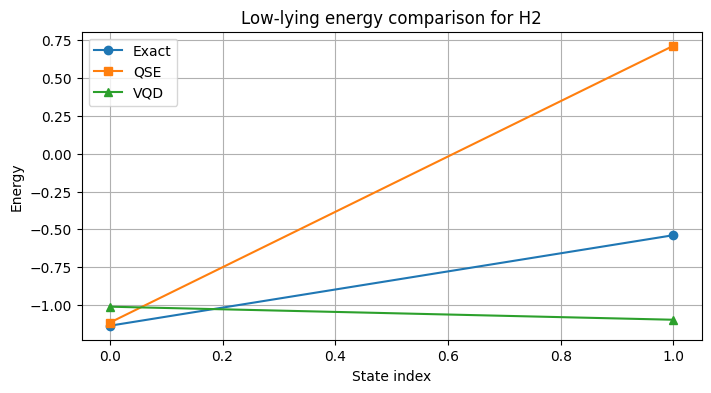

In [12]:
n_show = min(4, len(exact_spectrum), len(qse_eigs), len(vqd_energies))
state_idx = np.arange(n_show)

plt.figure(figsize=(8, 4))
plt.plot(state_idx, exact_spectrum[:n_show], marker="o", label="Exact")
plt.plot(state_idx, qse_eigs[:n_show], marker="s", label="QSE")
plt.plot(state_idx, vqd_energies[:n_show], marker="^", label="VQD")
plt.xlabel("State index")
plt.ylabel("Energy")
plt.title("Low-lying energy comparison for H2")
plt.grid(True)
plt.legend()
plt.show()

## Excitation-energy comparison plot

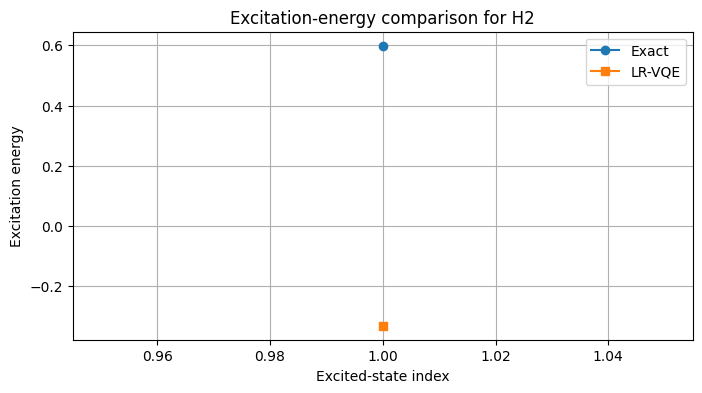

In [13]:
n_exc = min(3, len(exact_excitation_energies) - 1, len(lr_excitations))
exc_idx = np.arange(1, n_exc + 1)

plt.figure(figsize=(8, 4))
plt.plot(
    exc_idx,
    exact_excitation_energies[1 : n_exc + 1],
    marker="o",
    label="Exact",
)
plt.plot(
    exc_idx,
    lr_excitations[:n_exc],
    marker="s",
    label="LR-VQE",
)
plt.xlabel("Excited-state index")
plt.ylabel("Excitation energy")
plt.title("Excitation-energy comparison for H2")
plt.grid(True)
plt.legend()
plt.show()

## Interpretation

These methods target excited states in different ways:

- **QSE** builds an operator-generated subspace
- **LR-VQE** uses tangent-space response around a ground-state solution
- **VQD** solves states variationally with deflation

On a small system like `H2`, the exact spectrum gives a useful benchmark for
checking whether the reduced-model or variational approximations are behaving
reasonably.

## What this notebook showed

We:

- computed the exact low-lying spectrum of `H2`
- ran representative excited-state methods
- compared returned energies or excitation energies
- plotted the results against the exact reference

This gives a first overview of the excited-state tools in the repository.

## Next steps

Good follow-ups are:

- compare QSE, LR-VQE, EOM-VQE, and EOM-QSE on the same molecule
- compare VQD and SSVQE as variational excited-state solvers
- repeat the study on `H3+`